# 01 — Fragmentation Analysis with Super-Objects

Replicates **IndiFrag Tutorial 1** using open-source Python.

We intersect the LULC objects with district boundaries (super-objects),
then compute fragmentation metrics at three levels:

- **Object (O)** — each individual polygon
- **Class (Cl)** — all objects of the same land-use class within a district
- **Super-Object (SO)** — the district as a whole

This notebook covers the **Area & Perimeter**, **Shape**, and **Aggregation**
metric groups. Subsequent sections will add Diversity and Contrast.

In [1]:
import sys; sys.path.insert(0, "../src")

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pathlib import Path

from indifrag.metrics.area_perimeter import (
    object_metrics, class_metrics, super_object_metrics
)
from indifrag.metrics import shape as shape_metrics
from indifrag.metrics import aggregation as agg_metrics

DATA_DIR = Path("../data/valencia")
TARGET_CRS = "EPSG:25830"

# Shared lookups
CLASS_NAMES = {
    1: "Agricultural", 2: "Barrenland", 3: "Commercial",
    4: "Green Urban Areas", 5: "Leisure Facilities",
    6: "Residential", 7: "Roads", 8: "Water",
}
CLASS_COLORS = {
    1: "#ffffbe", 2: "#e6a600", 3: "#ff8c00", 4: "#a3d774",
    5: "#267300", 6: "#c8374b", 7: "#cccccc", 8: "#73b2ff",
}
DISTRICT_NAMES = {
    "4625001": "Ciutat Vella", "4625002": "Eixample",
    "4625003": "Extramurs", "4625007": "L'Olivereta",
    "4625008": "Patraix", "4625009": "Jesús",
    "4625010": "Quatre Carreres",
}

## 1. Load and prepare data

In [2]:
objects_raw = gpd.read_file(
    DATA_DIR / "ES003L2_VALENCIA_UA2006_Revised_Clipped_to_Core.shp"
).to_crs(TARGET_CRS)

districts = gpd.read_file(DATA_DIR / "VALENCIA_DISTR.shp").to_crs(TARGET_CRS)
districts["name"] = districts["CUDIS"].map(DISTRICT_NAMES)

centre = gpd.read_file(DATA_DIR / "VALENCIA_Centre_Point.shp").to_crs(TARGET_CRS)

print(f"Raw objects: {len(objects_raw)}")
print(f"Districts:   {len(districts)}")

Raw objects: 1958
Districts:   7


## 2. Intersect objects with districts

IndiFrag clips every LULC polygon at district boundaries, so objects that
straddle two districts are split into separate pieces.  This is the key
difference from a simple centroid-based spatial join.

In [3]:
objects_int = gpd.overlay(
    objects_raw,
    districts[["CUDIS", "name", "geometry"]],
    how="intersection",
)
objects_int["class_name"] = objects_int["CLASS"].map(CLASS_NAMES)

print(f"Objects after intersection: {len(objects_int)}  (was {len(objects_raw)})")
print(f"New fragments created:      {len(objects_int) - len(objects_raw)}")

Objects after intersection: 2032  (was 1958)
New fragments created:      74


## 3. Compute area and perimeter metrics

In [4]:
# Object level
objects_int = object_metrics(objects_int)

# Class level
cl_metrics = class_metrics(objects_int, class_col="CLASS", so_col="CUDIS")
cl_metrics["class_name"] = cl_metrics["CLASS"].map(CLASS_NAMES)
cl_metrics["district"] = cl_metrics["SO"].map(DISTRICT_NAMES)

# Super-object level
so_metrics = super_object_metrics(objects_int, districts, class_col="CLASS", so_col="CUDIS")
so_metrics["district"] = so_metrics["CUDIS"].map(DISTRICT_NAMES)

print("Object-level metrics computed for", len(objects_int), "polygons")
print("Class-level metrics:", len(cl_metrics), "rows (class x district)")
print("Super-object metrics:", len(so_metrics), "districts")

Object-level metrics computed for 2032 polygons
Class-level metrics: 45 rows (class x district)
Super-object metrics: 7 districts


## 3b. Compute shape metrics

Four metrics describe the **geometric complexity** of patches:

| Metric | Name | Formula | Level |
|--------|------|---------|-------|
| **DF** | Fractal dimension | `2 · ln(0.25·P) / ln(A)` | O, Cl, SO |
| **DFP** | Area-weighted fractal dimension | `Σ(DF_i · A_i) / Σ A_i` | Cl |
| **IF** | Shape index | `0.25 · P / √A` | O, Cl, SO |
| **RMPA** | Mean perimeter-area ratio | `mean(P_i / A_i)` | Cl, SO |

- DF ≈ 1.0 for simple shapes, approaching 2.0 for highly convoluted boundaries.
- IF = 1.0 for a perfect square; higher values indicate more complex shapes.

In [5]:
# Object level — adds DF, IF columns
objects_int = shape_metrics.object_metrics(objects_int)

# Class level
cl_shape = shape_metrics.class_metrics(objects_int, class_col="CLASS", so_col="CUDIS")
cl_shape["class_name"] = cl_shape["CLASS"].map(CLASS_NAMES)
cl_shape["district"] = cl_shape["SO"].map(DISTRICT_NAMES)

# Super-object level
so_shape = shape_metrics.super_object_metrics(objects_int, districts)
so_shape["district"] = so_shape["CUDIS"].map(DISTRICT_NAMES)

print("Shape metrics computed.")
print(f"  Object-level: DF and IF added to {len(objects_int)} polygons")
print(f"  Class-level:  {len(cl_shape)} rows")
print(f"  SO-level:     {len(so_shape)} districts")
print()
print("Class-level sample:")
cl_shape.head(8)

Shape metrics computed.
  Object-level: DF and IF added to 2032 polygons
  Class-level:  45 rows
  SO-level:     7 districts

Class-level sample:


,CLASS,SO,DF,DFP,IF,RMPA,class_name,district
0,2,4625001,1.090885,1.011973,1.482835,0.077797,Barrenland,Ciutat Vella
1,3,4625001,1.308347,1.020616,6.664577,0.071591,Commercial,Ciutat Vella
2,4,4625001,1.223634,1.055322,3.844121,0.055531,Green Urban Areas,Ciutat Vella
3,5,4625001,1.126343,1.014958,1.994118,0.062547,Leisure Facilities,Ciutat Vella
4,6,4625001,1.425488,1.036893,18.493348,0.093008,Residential,Ciutat Vella
5,7,4625001,1.560361,1.505736,36.220609,0.610312,Roads,Ciutat Vella
6,2,4625002,1.044766,1.044766,1.244420,0.037635,Barrenland,Eixample
7,3,4625002,1.200078,1.052262,3.284683,0.051181,Commercial,Eixample


## 3c. Compute aggregation metrics

Ten metrics describe how objects are **spatially distributed and clustered**
within super-objects:

| Metric | Name | Level | Description |
|--------|------|-------|-------------|
| **Nob** | Object count | Cl, SO | Number of objects |
| **DO** | Object density | Cl, SO | Objects per km² |
| **DEP** | Dispersion | Cl, SO | Area-weighted standard distance (km) |
| **DEM** | Mean nearest-neighbour | Cl only | Mean boundary-to-boundary distance (km) |
| **TEM** | Effective mesh size | Cl, SO | Σ(A²)/A_T (km²) |
| **COHE** | Patch cohesion | Cl, SO | Connectivity index (0–1) |
| **IS** | Splitting index | Cl, SO | A_T²/Σ(A²), higher = more fragmented |
| **GC** | Concentration | Cl, SO | Σ(A/A_T)², higher = fewer large objects |
| **CU** | Urban compactness | SO only | Compactness of urban objects (0–1) |
| **C** | Class compactness | Cl only | 2·√(π·ΣA)/ΣP (0–1) |

In [6]:
# Class level — needs districts_gdf for SO area (A_T)
cl_agg = agg_metrics.class_metrics(objects_int, districts, class_col="CLASS", so_col="CUDIS")
cl_agg["class_name"] = cl_agg["CLASS"].map(CLASS_NAMES)
cl_agg["district"] = cl_agg["SO"].map(DISTRICT_NAMES)

# Super-object level — urban classes: Residential (6) + Commercial (3)
so_agg = agg_metrics.super_object_metrics(
    objects_int, districts,
    class_col="CLASS", so_col="CUDIS",
    urban_classes={3, 6},
)
so_agg["district"] = so_agg["CUDIS"].map(DISTRICT_NAMES)

print("Aggregation metrics computed.")
print(f"  Class-level:  {len(cl_agg)} rows")
print(f"  SO-level:     {len(so_agg)} districts")
print()
print("Class-level sample (first 8 rows):")
cl_agg.head(8)

Aggregation metrics computed.
  Class-level:  45 rows
  SO-level:     7 districts

Class-level sample (first 8 rows):


,CLASS,SO,Nob,DO,DEP,DEM,TEM,COHE,IS,GC,C,class_name,district
0,2,4625001,2,1.162166,0.027722,0.892010,0.000010,0.982222,174390.226726,0.000006,0.597657,Barrenland,Ciutat Vella
1,3,4625001,43,24.986566,0.193023,0.030699,0.001138,0.987895,1512.231958,0.000661,0.132976,Commercial,Ciutat Vella
2,4,4625001,11,6.391912,0.194733,0.079769,0.002646,0.993806,650.419494,0.001537,0.230541,Green Urban Areas,Ciutat Vella
3,5,4625001,4,2.324332,0.077644,0.262663,0.000677,0.992912,2542.950655,0.000393,0.444421,Leisure Facilities,Ciutat Vella
4,6,4625001,281,163.284304,0.358069,0.005714,0.002638,0.984326,652.368070,0.001533,0.047921,Residential,Ciutat Vella
5,7,4625001,13,7.554078,0.184707,0.000000,0.026921,0.997784,63.924581,0.015643,0.024467,Roads,Ciutat Vella
6,2,4625002,1,0.576020,0.000000,NaN,0.000176,0.993193,9848.984128,0.000102,0.712160,Barrenland,Eixample
7,3,4625002,10,5.760204,0.151681,0.127532,0.003781,0.994503,459.191589,0.002178,0.269806,Commercial,Eixample


---

## 4. Visualising the metrics

### 4.1 Object-level: area distribution by class

How large are individual LULC patches?  Residential parcels are typically
small and numerous, while agricultural areas are few but large.

/var/folders/bw/6_mkq89x0xb15pw90d214mx80000gn/T/ipykernel_18272/1326081495.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


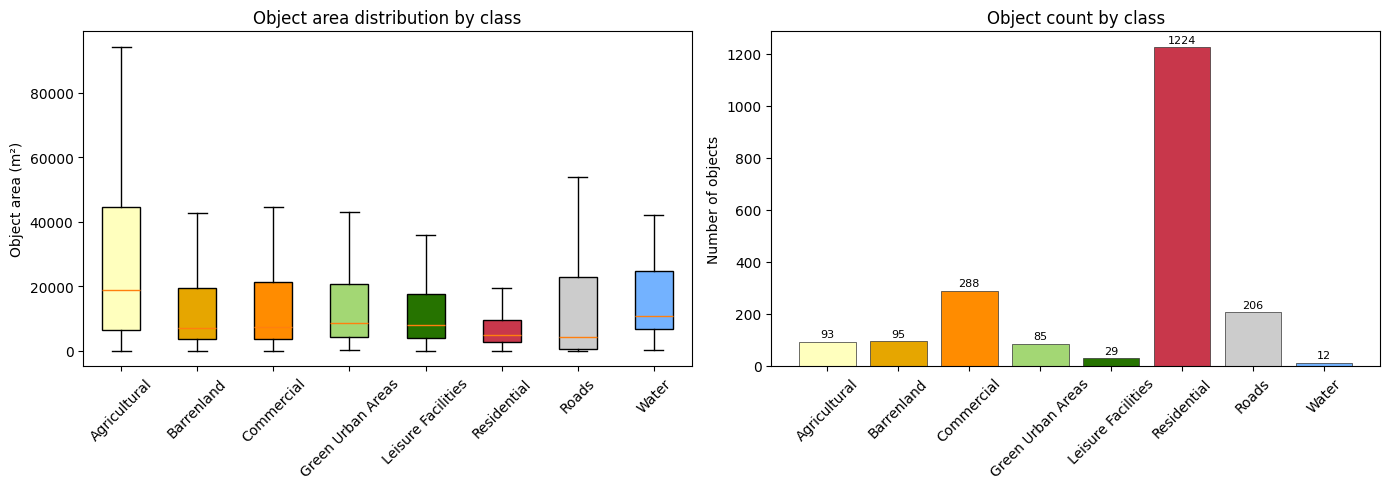

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: box plot of object areas by class
class_order = sorted(CLASS_NAMES.keys())
data_by_class = [
    objects_int.loc[objects_int["CLASS"] == c, "AreaO"].values * 1e6  # back to m²
    for c in class_order
]
bp = axes[0].boxplot(
    data_by_class, vert=True, patch_artist=True, showfliers=False,
    labels=[CLASS_NAMES[c] for c in class_order],
)
for patch, c in zip(bp["boxes"], class_order):
    patch.set_facecolor(CLASS_COLORS[c])
axes[0].set_ylabel("Object area (m²)")
axes[0].set_title("Object area distribution by class")
axes[0].tick_params(axis="x", rotation=45)

# Right: count of objects per class
counts = objects_int.groupby("CLASS").size()
bars = axes[1].bar(
    [CLASS_NAMES[c] for c in counts.index],
    counts.values,
    color=[CLASS_COLORS[c] for c in counts.index],
    edgecolor="#333333", linewidth=0.5,
)
axes[1].set_ylabel("Number of objects")
axes[1].set_title("Object count by class")
axes[1].tick_params(axis="x", rotation=45)
for bar, v in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 10, str(v),
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/figures/01_object_area_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.2 Class level: class density (DC) by district

**DC** = AreaCl / AreaSO — what proportion of each district is occupied by each class?

This is the land-use composition fingerprint of each district.

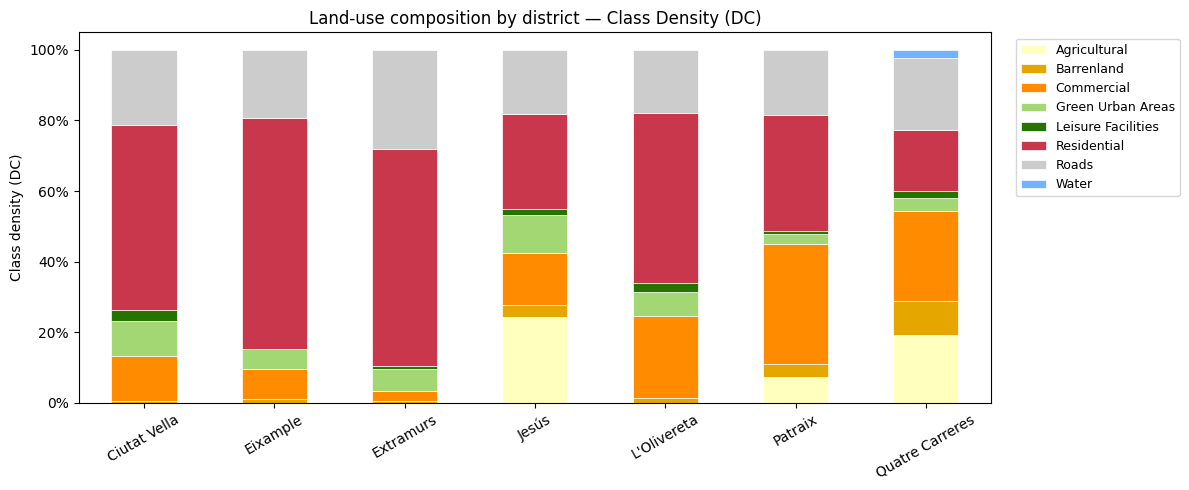

In [8]:
# Pivot DC to a matrix: districts × classes
dc_pivot = cl_metrics.pivot_table(
    index="district", columns="class_name", values="DC", fill_value=0
)
# Order columns by class id
col_order = [CLASS_NAMES[c] for c in sorted(CLASS_NAMES.keys()) if CLASS_NAMES[c] in dc_pivot.columns]
dc_pivot = dc_pivot[col_order]

fig, ax = plt.subplots(figsize=(12, 5))
dc_pivot.plot.bar(
    stacked=True, ax=ax,
    color=[CLASS_COLORS[c] for c in sorted(CLASS_NAMES.keys()) if CLASS_NAMES[c] in dc_pivot.columns],
    edgecolor="white", linewidth=0.5,
)
ax.set_ylabel("Class density (DC)")
ax.set_title("Land-use composition by district — Class Density (DC)")
ax.set_xlabel("")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../outputs/figures/01_class_density_stacked.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.3 Choropleth map: residential density per district

Map the class density of **Residential** (class 6) across the seven districts.
Darker = higher proportion of the district is residential.

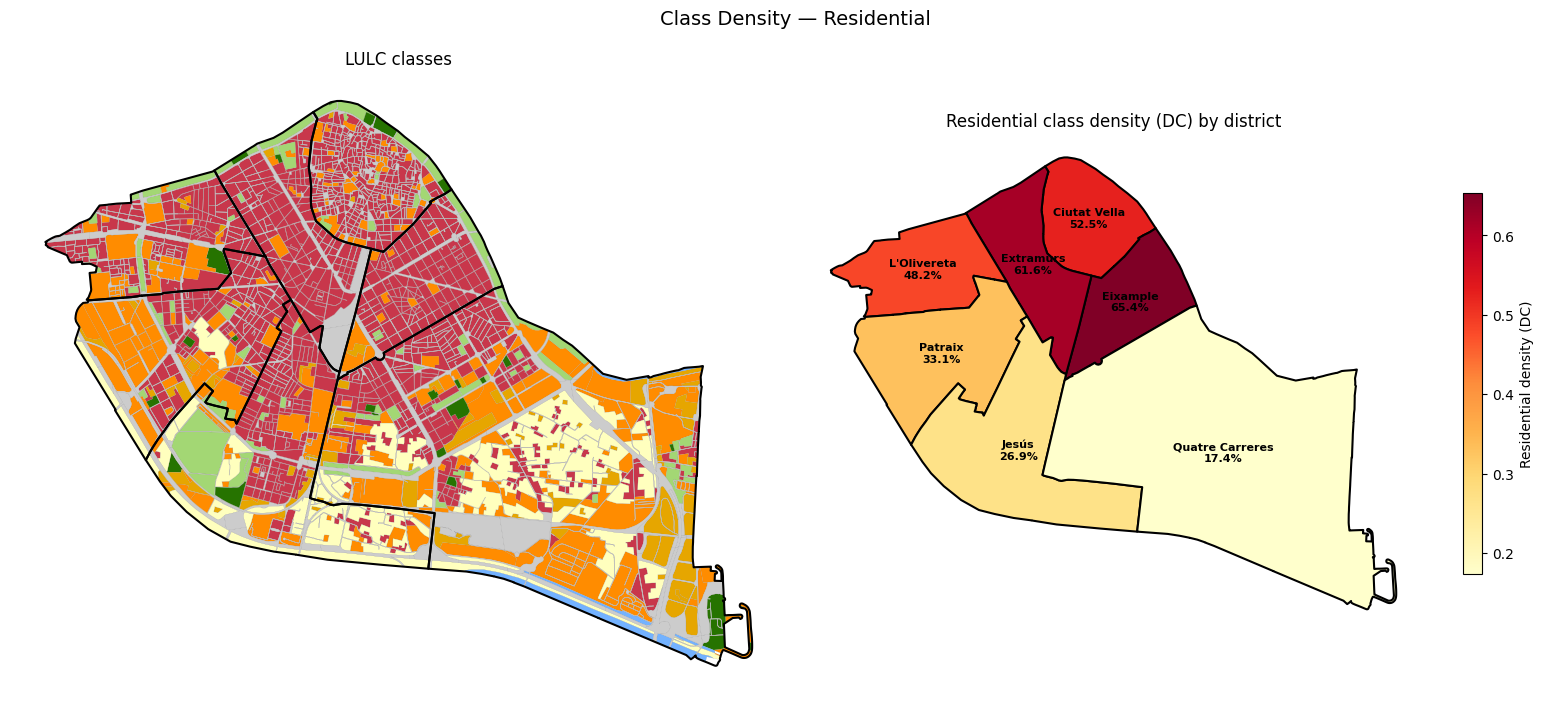

In [9]:
# Merge residential DC into districts GeoDataFrame
residential_dc = cl_metrics.loc[
    cl_metrics["CLASS"] == 6, ["SO", "DC"]
].rename(columns={"SO": "CUDIS", "DC": "DC_residential"})

districts_plot = districts.merge(residential_dc, on="CUDIS", how="left")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: LULC map
objects_int.plot(
    ax=axes[0],
    color=objects_int["CLASS"].map(CLASS_COLORS),
    edgecolor="#888888", linewidth=0.1,
)
districts.boundary.plot(ax=axes[0], color="black", linewidth=1.5)
axes[0].set_title("LULC classes", fontsize=12)
axes[0].set_axis_off()

# Right: Residential DC choropleth
districts_plot.plot(
    ax=axes[1], column="DC_residential",
    cmap="YlOrRd", edgecolor="black", linewidth=1.5,
    legend=True, legend_kwds={"label": "Residential density (DC)", "shrink": 0.6},
)
for _, row in districts_plot.iterrows():
    c = row.geometry.centroid
    axes[1].annotate(
        f"{row['name']}\n{row['DC_residential']:.1%}",
        xy=(c.x, c.y), ha="center", va="center", fontsize=8, fontweight="bold",
    )
axes[1].set_title("Residential class density (DC) by district", fontsize=12)
axes[1].set_axis_off()

plt.suptitle("Class Density — Residential", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/01_residential_dc_map.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.4 Super-object level: district profiles

Compare districts on area, total perimeter, number of objects, and class count.

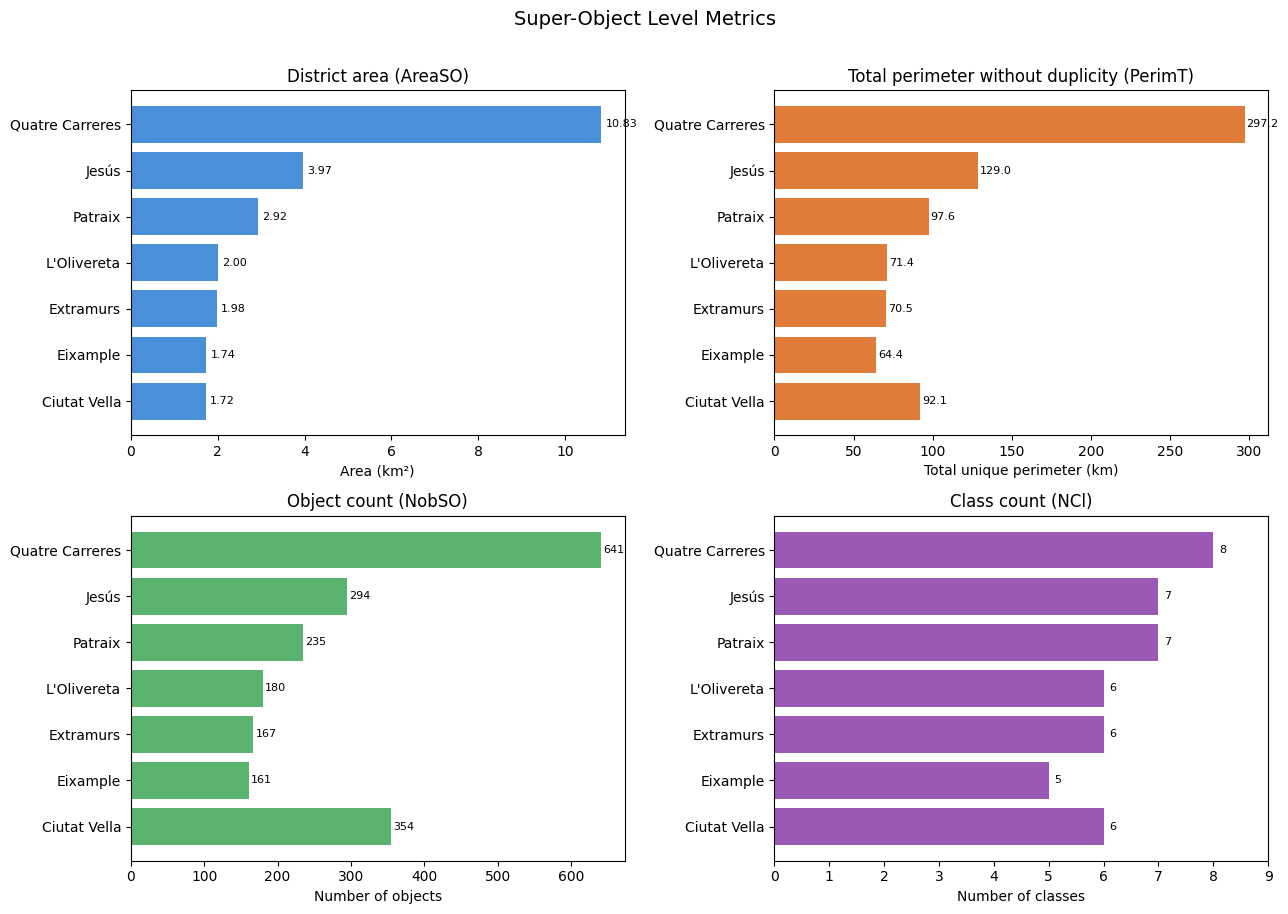

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

so_sorted = so_metrics.sort_values("AreaSO")
bar_color = "#4a90d9"

# AreaSO
axes[0,0].barh(so_sorted["district"], so_sorted["AreaSO"], color=bar_color)
axes[0,0].set_xlabel("Area (km²)")
axes[0,0].set_title("District area (AreaSO)")
for i, v in enumerate(so_sorted["AreaSO"]):
    axes[0,0].text(v + 0.1, i, f"{v:.2f}", va="center", fontsize=8)

# PerimT
axes[0,1].barh(so_sorted["district"], so_sorted["PerimT"], color="#e07b39")
axes[0,1].set_xlabel("Total unique perimeter (km)")
axes[0,1].set_title("Total perimeter without duplicity (PerimT)")
for i, v in enumerate(so_sorted["PerimT"]):
    axes[0,1].text(v + 1, i, f"{v:.1f}", va="center", fontsize=8)

# NobSO
axes[1,0].barh(so_sorted["district"], so_sorted["NobSO"], color="#5bb370")
axes[1,0].set_xlabel("Number of objects")
axes[1,0].set_title("Object count (NobSO)")
for i, v in enumerate(so_sorted["NobSO"]):
    axes[1,0].text(v + 3, i, str(int(v)), va="center", fontsize=8)

# NCl
axes[1,1].barh(so_sorted["district"], so_sorted["NCl"], color="#9b59b6")
axes[1,1].set_xlabel("Number of classes")
axes[1,1].set_title("Class count (NCl)")
axes[1,1].set_xlim(0, 9)
for i, v in enumerate(so_sorted["NCl"]):
    axes[1,1].text(v + 0.1, i, str(int(v)), va="center", fontsize=8)

plt.suptitle("Super-Object Level Metrics", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/01_super_object_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.5 Object-level: shape complexity by class

How complex are the boundaries of individual patches?
Roads and water features tend to have more irregular shapes (higher DF and IF),
while residential parcels are more regular.

/var/folders/bw/6_mkq89x0xb15pw90d214mx80000gn/T/ipykernel_18272/3419316339.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(
/var/folders/bw/6_mkq89x0xb15pw90d214mx80000gn/T/ipykernel_18272/3419316339.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(


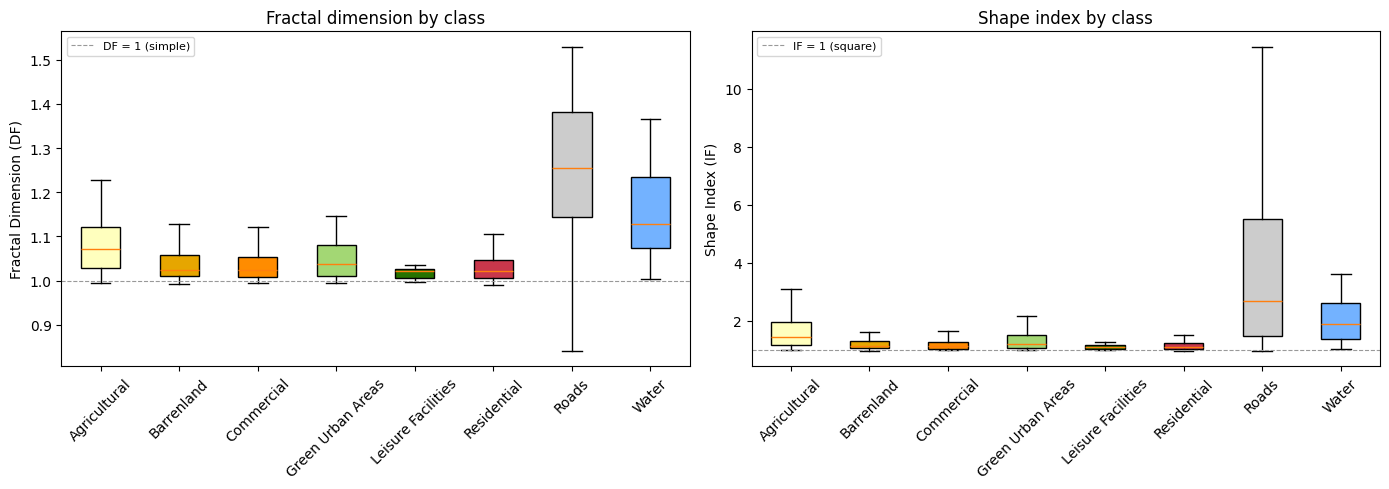

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_order = sorted(CLASS_NAMES.keys())

# Left: fractal dimension (DF) by class
data_df = [
    objects_int.loc[objects_int["CLASS"] == c, "DF"].dropna().values
    for c in class_order
]
bp = axes[0].boxplot(
    data_df, vert=True, patch_artist=True, showfliers=False,
    labels=[CLASS_NAMES[c] for c in class_order],
)
for patch, c in zip(bp["boxes"], class_order):
    patch.set_facecolor(CLASS_COLORS[c])
axes[0].set_ylabel("Fractal Dimension (DF)")
axes[0].set_title("Fractal dimension by class")
axes[0].axhline(1.0, color="#999999", linestyle="--", linewidth=0.8, label="DF = 1 (simple)")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=45)

# Right: shape index (IF) by class
data_if = [
    objects_int.loc[objects_int["CLASS"] == c, "IF"].dropna().values
    for c in class_order
]
bp2 = axes[1].boxplot(
    data_if, vert=True, patch_artist=True, showfliers=False,
    labels=[CLASS_NAMES[c] for c in class_order],
)
for patch, c in zip(bp2["boxes"], class_order):
    patch.set_facecolor(CLASS_COLORS[c])
axes[1].set_ylabel("Shape Index (IF)")
axes[1].set_title("Shape index by class")
axes[1].axhline(1.0, color="#999999", linestyle="--", linewidth=0.8, label="IF = 1 (square)")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../outputs/figures/01_shape_object_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.6 Class level: area-weighted fractal dimension (DFP) by district

**DFP** is the area-weighted mean of object-level fractal dimensions within
each class-district group.  Higher values indicate that large patches
have more complex boundaries.

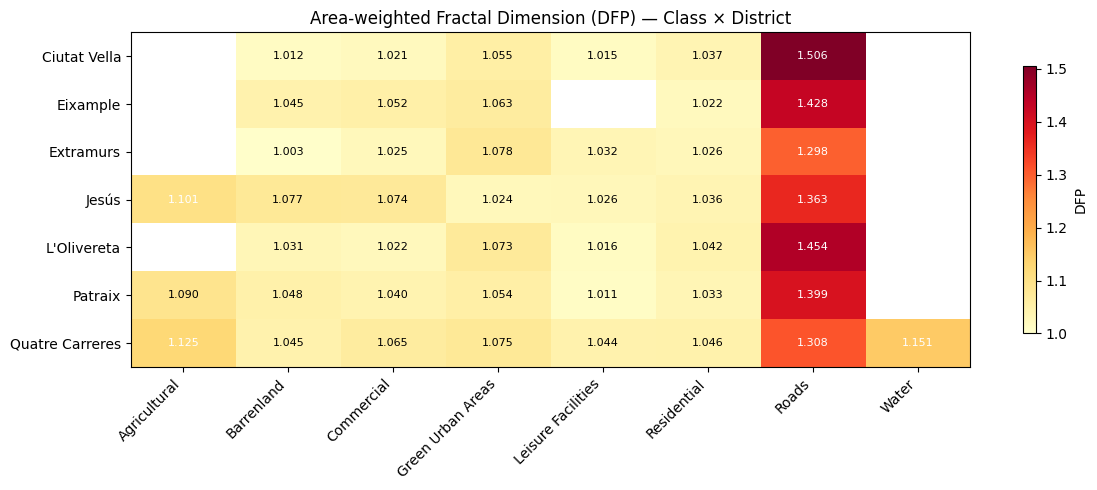

In [12]:
# Heatmap: DFP by class × district
dfp_pivot = cl_shape.pivot_table(
    index="district", columns="class_name", values="DFP", fill_value=np.nan
)
col_order = [CLASS_NAMES[c] for c in sorted(CLASS_NAMES.keys()) if CLASS_NAMES[c] in dfp_pivot.columns]
dfp_pivot = dfp_pivot[col_order]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(dfp_pivot.values, aspect="auto", cmap="YlOrRd", vmin=1.0)
ax.set_xticks(range(len(dfp_pivot.columns)))
ax.set_xticklabels(dfp_pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(dfp_pivot.index)))
ax.set_yticklabels(dfp_pivot.index)

# Annotate cells
for i in range(len(dfp_pivot.index)):
    for j in range(len(dfp_pivot.columns)):
        val = dfp_pivot.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8,
                    color="white" if val > 1.1 else "black")

cb = fig.colorbar(im, ax=ax, shrink=0.8, label="DFP")
ax.set_title("Area-weighted Fractal Dimension (DFP) — Class × District")
plt.tight_layout()
plt.savefig("../outputs/figures/01_shape_dfp_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.7 Super-object level: district shape complexity

DF and IF at the district level reflect the regularity of district
boundaries themselves, while RMPA captures the average shape complexity
of all patches within each district.

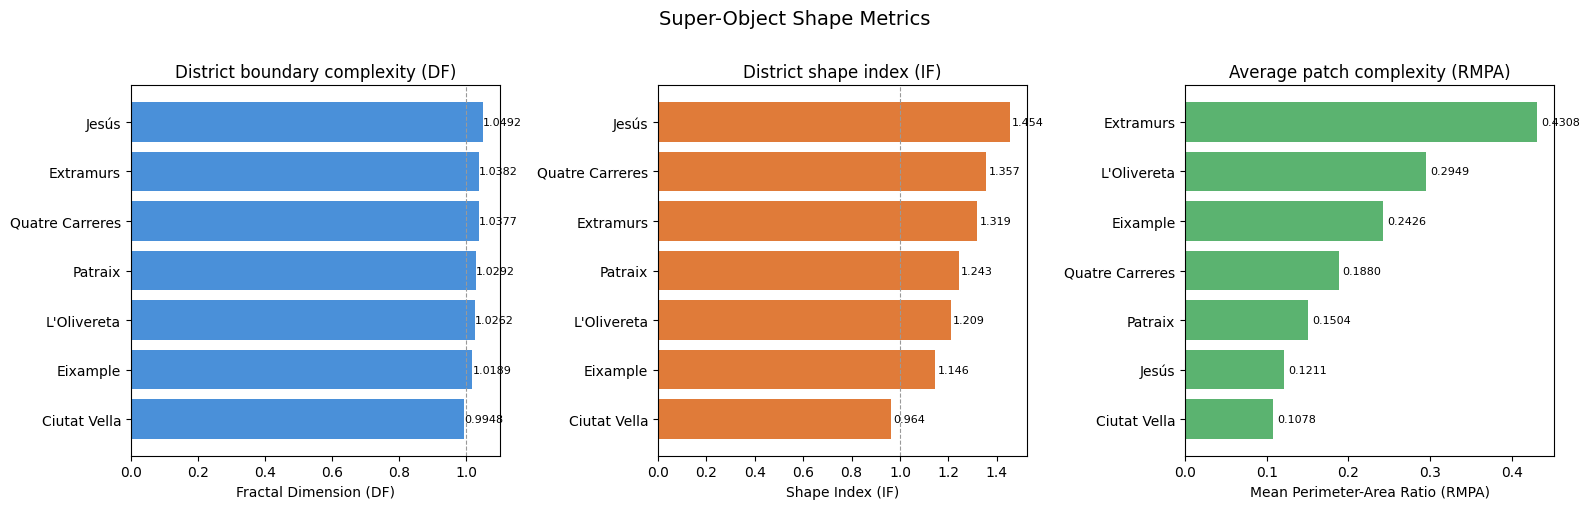

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

so_sorted = so_shape.sort_values("DF")

# DF
axes[0].barh(so_sorted["district"], so_sorted["DF"], color="#4a90d9")
axes[0].set_xlabel("Fractal Dimension (DF)")
axes[0].set_title("District boundary complexity (DF)")
axes[0].axvline(1.0, color="#999999", linestyle="--", linewidth=0.8)
for i, v in enumerate(so_sorted["DF"]):
    axes[0].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)

# IF
so_sorted_if = so_shape.sort_values("IF")
axes[1].barh(so_sorted_if["district"], so_sorted_if["IF"], color="#e07b39")
axes[1].set_xlabel("Shape Index (IF)")
axes[1].set_title("District shape index (IF)")
axes[1].axvline(1.0, color="#999999", linestyle="--", linewidth=0.8)
for i, v in enumerate(so_sorted_if["IF"]):
    axes[1].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)

# RMPA
so_sorted_r = so_shape.sort_values("RMPA")
axes[2].barh(so_sorted_r["district"], so_sorted_r["RMPA"], color="#5bb370")
axes[2].set_xlabel("Mean Perimeter-Area Ratio (RMPA)")
axes[2].set_title("Average patch complexity (RMPA)")
for i, v in enumerate(so_sorted_r["RMPA"]):
    axes[2].text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=8)

plt.suptitle("Super-Object Shape Metrics", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/01_shape_SO_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.8 Class level: object density (DO) heatmap

**DO** = number of objects per km² of the super-object.
Higher density indicates more fragmented land use.

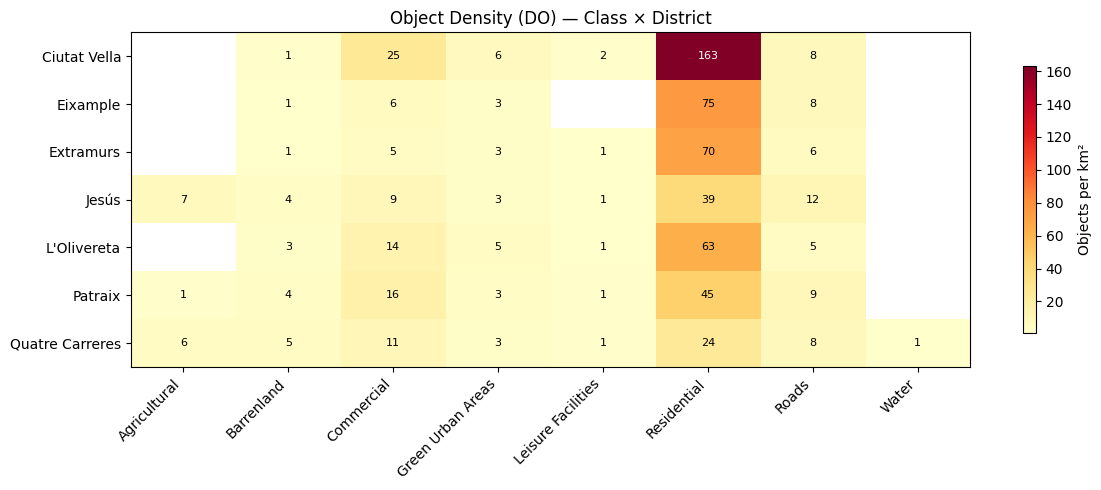

In [14]:
# Heatmap: DO by class × district
do_pivot = cl_agg.pivot_table(
    index="district", columns="class_name", values="DO", fill_value=np.nan
)
col_order = [CLASS_NAMES[c] for c in sorted(CLASS_NAMES.keys()) if CLASS_NAMES[c] in do_pivot.columns]
do_pivot = do_pivot[col_order]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(do_pivot.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(do_pivot.columns)))
ax.set_xticklabels(do_pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(do_pivot.index)))
ax.set_yticklabels(do_pivot.index)

for i in range(len(do_pivot.index)):
    for j in range(len(do_pivot.columns)):
        val = do_pivot.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=8,
                    color="white" if val > do_pivot.max().max() * 0.5 else "black")

fig.colorbar(im, ax=ax, shrink=0.8, label="Objects per km²")
ax.set_title("Object Density (DO) — Class × District")
plt.tight_layout()
plt.savefig("../outputs/figures/01_agg_DO_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.9 Class level: mean nearest-neighbour distance (DEM) by class

**DEM** is the average boundary-to-boundary distance between objects of the
same class within a district. Lower values = objects are closer together
(more clustered). NaN when only one object of that class exists.

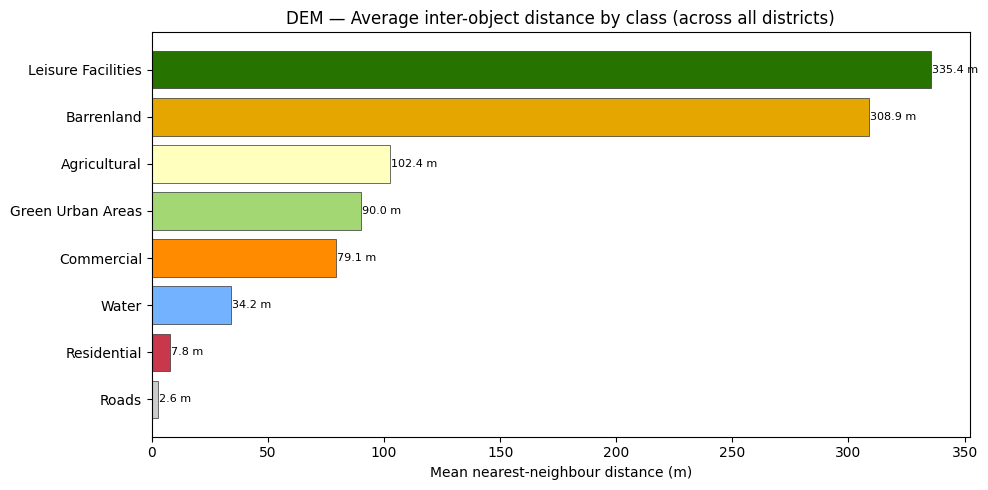

In [15]:
# Bar chart: DEM by class, averaged across districts
dem_by_class = cl_agg.groupby("class_name")["DEM"].mean().dropna().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = [CLASS_COLORS[k] for k in sorted(CLASS_NAMES.keys())
          if CLASS_NAMES[k] in dem_by_class.index]
# Reorder colors to match sorted values
color_map = {CLASS_NAMES[k]: CLASS_COLORS[k] for k in CLASS_NAMES}
bar_colors = [color_map[name] for name in dem_by_class.index]

bars = ax.barh(dem_by_class.index, dem_by_class.values * 1e3, color=bar_colors,
               edgecolor="#333333", linewidth=0.5)  # km → m for readability
for bar, v in zip(bars, dem_by_class.values * 1e3):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2,
            f"{v:.1f} m", va="center", fontsize=8)
ax.set_xlabel("Mean nearest-neighbour distance (m)")
ax.set_title("DEM — Average inter-object distance by class (across all districts)")
plt.tight_layout()
plt.savefig("../outputs/figures/01_agg_DEM_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.10 Super-object level: aggregation profiles

Compare districts on key aggregation metrics: object density (DO),
effective mesh size (TEM), patch cohesion (COHE), and urban compactness (CU).

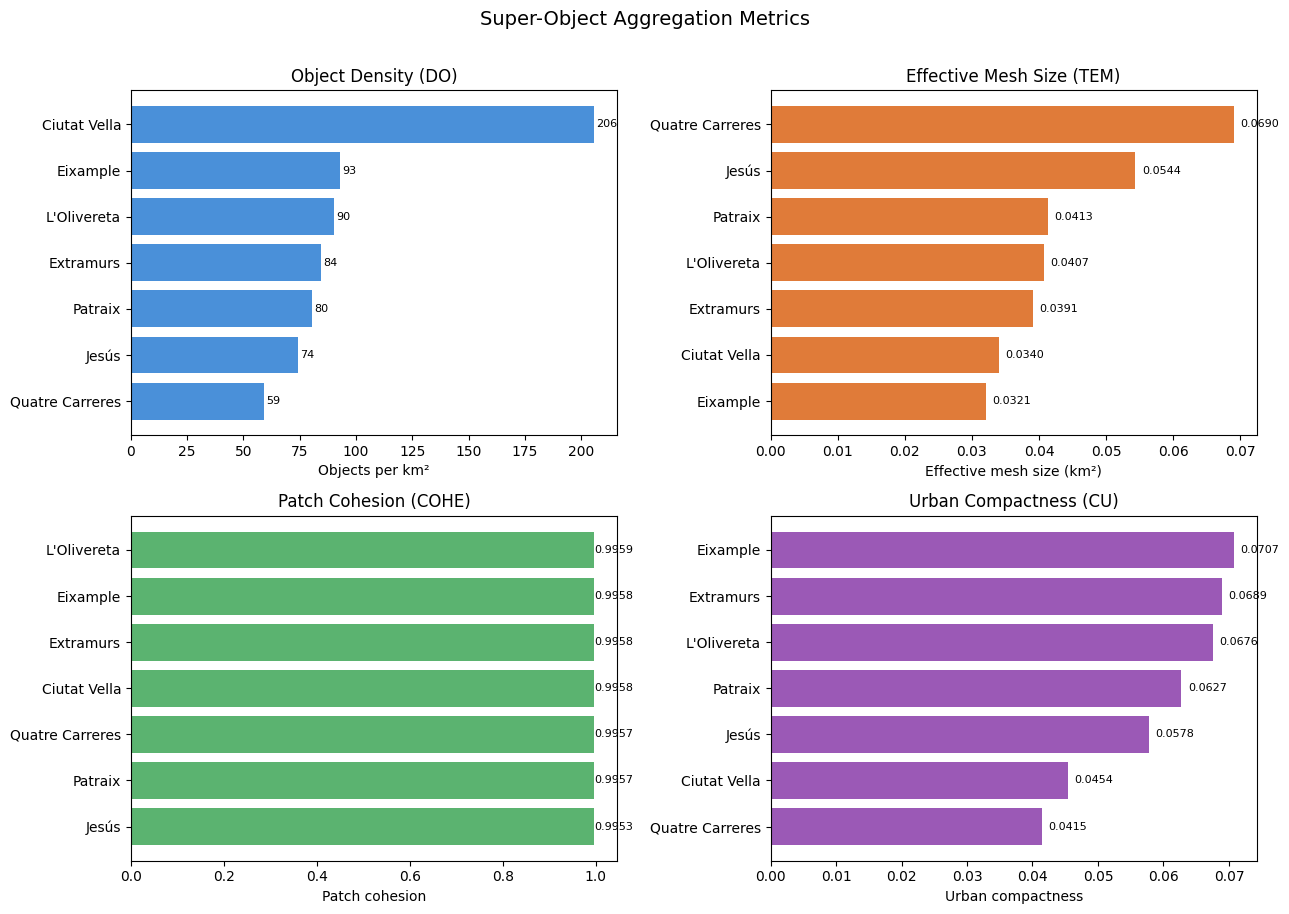

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
bar_color = "#4a90d9"

so_sorted = so_agg.sort_values("DO")

# DO
axes[0,0].barh(so_sorted["district"], so_sorted["DO"], color=bar_color)
axes[0,0].set_xlabel("Objects per km²")
axes[0,0].set_title("Object Density (DO)")
for i, v in enumerate(so_sorted["DO"]):
    axes[0,0].text(v + 1, i, f"{v:.0f}", va="center", fontsize=8)

# TEM
so_sorted_t = so_agg.sort_values("TEM")
axes[0,1].barh(so_sorted_t["district"], so_sorted_t["TEM"], color="#e07b39")
axes[0,1].set_xlabel("Effective mesh size (km²)")
axes[0,1].set_title("Effective Mesh Size (TEM)")
for i, v in enumerate(so_sorted_t["TEM"]):
    axes[0,1].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)

# COHE
so_sorted_c = so_agg.sort_values("COHE")
axes[1,0].barh(so_sorted_c["district"], so_sorted_c["COHE"], color="#5bb370")
axes[1,0].set_xlabel("Patch cohesion")
axes[1,0].set_title("Patch Cohesion (COHE)")
for i, v in enumerate(so_sorted_c["COHE"]):
    axes[1,0].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)

# CU
so_sorted_cu = so_agg.sort_values("CU")
axes[1,1].barh(so_sorted_cu["district"], so_sorted_cu["CU"], color="#9b59b6")
axes[1,1].set_xlabel("Urban compactness")
axes[1,1].set_title("Urban Compactness (CU)")
for i, v in enumerate(so_sorted_cu["CU"]):
    axes[1,1].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)

plt.suptitle("Super-Object Aggregation Metrics", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/01_agg_SO_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 5. Validation against IndiFrag

Compare our computed values with the expected results from IndiFrag.
Small differences are expected due to geometric precision in the overlay operation.

In [17]:
# Load expected results
exp_so = pd.read_csv("../reference/expected_results/Results_FI_SO.txt", sep="\t", skiprows=4)
exp_so.columns = exp_so.columns.str.strip()
exp_so["CUDIS"] = exp_so["CUDIS"].astype(str)
exp_so["district"] = exp_so["CUDIS"].map(DISTRICT_NAMES)

exp_cl = pd.read_csv(
    "../reference/expected_results/Results_FI_Cls.txt",
    sep="\t", skiprows=4,
)
exp_cl.columns = exp_cl.columns.str.strip()
exp_cl["SO"] = exp_cl["SO"].astype(str)
exp_cl.rename(columns={"CLASE": "CLASS"}, inplace=True)

### 5.1 Super-object level validation

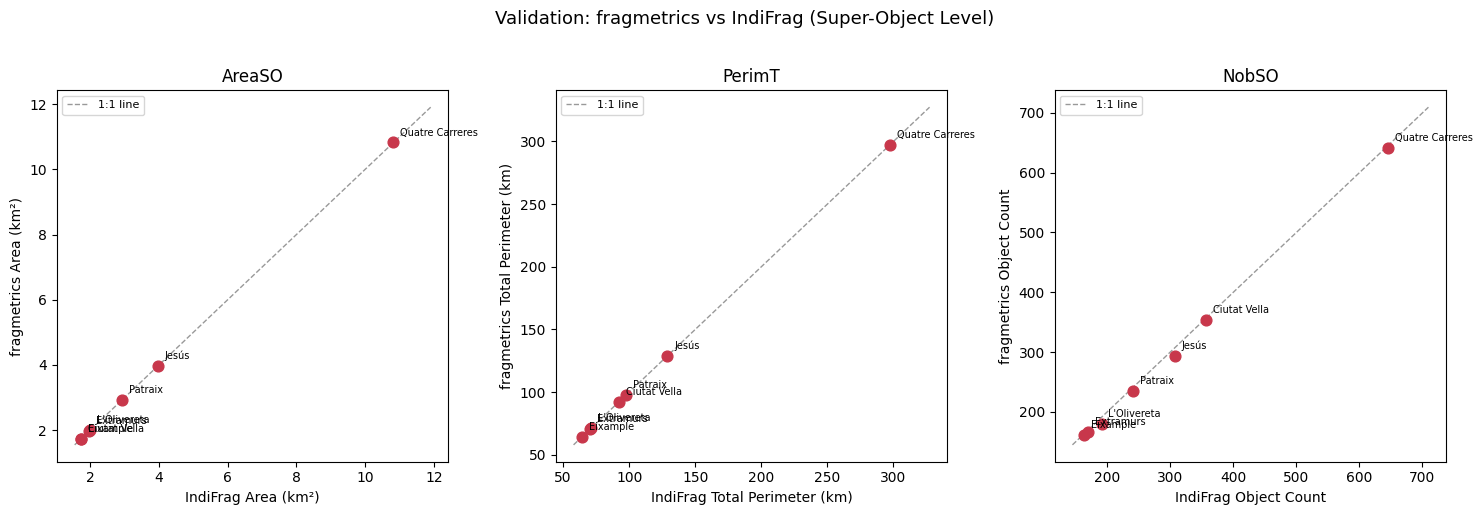

In [18]:
comp_so = so_metrics.merge(exp_so, on="CUDIS", suffixes=("_ours", "_exp"))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, label in zip(axes, ["AreaSO", "PerimT", "NobSO"],
                                ["Area (km²)", "Total Perimeter (km)", "Object Count"]):
    ours = comp_so[f"{col}_ours"]
    exp = comp_so[f"{col}_exp"]
    lo = min(ours.min(), exp.min()) * 0.9
    hi = max(ours.max(), exp.max()) * 1.1
    ax.plot([lo, hi], [lo, hi], "--", color="#999999", linewidth=1, label="1:1 line")
    ax.scatter(exp, ours, s=60, color="#c8374b", zorder=3)
    for _, r in comp_so.iterrows():
        ax.annotate(r["district_ours"], (r[f"{col}_exp"], r[f"{col}_ours"]),
                    fontsize=7, xytext=(5, 5), textcoords="offset points")
    ax.set_xlabel(f"IndiFrag {label}")
    ax.set_ylabel(f"fragmetrics {label}")
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle("Validation: fragmetrics vs IndiFrag (Super-Object Level)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/01_validation_SO.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 Class level validation

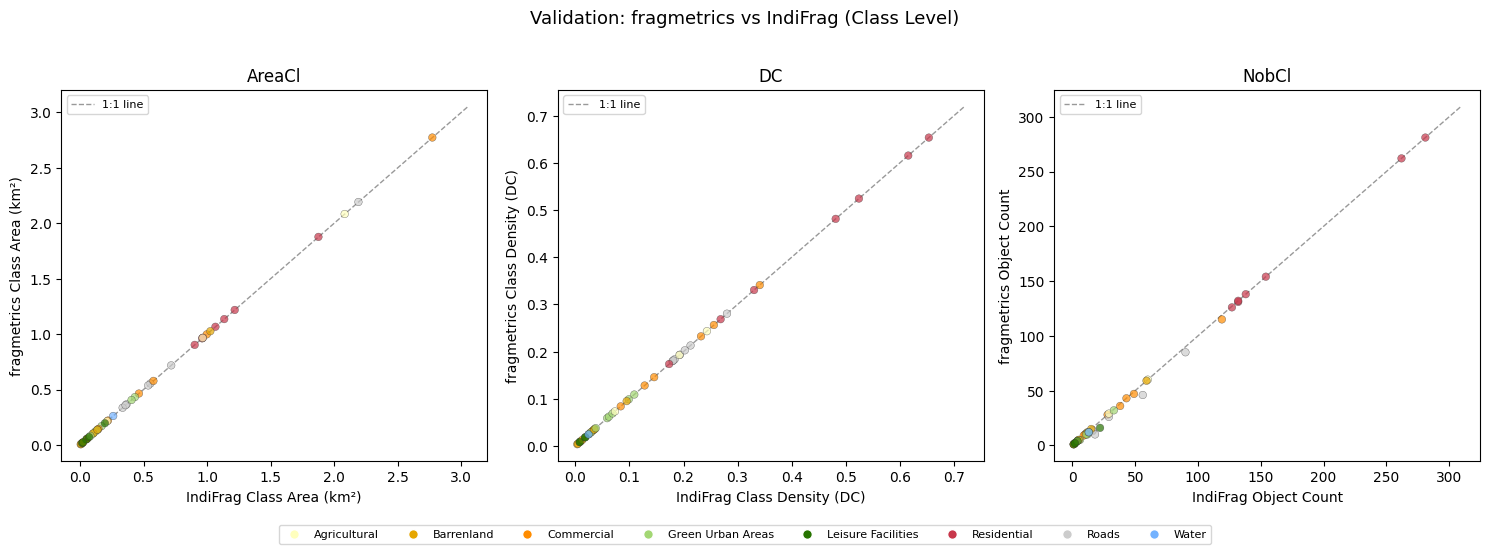

In [19]:
comp_cl = cl_metrics.merge(
    exp_cl[["CLASS", "SO", "AreaCl", "PerimCl", "NobCl", "DC"]],
    on=["CLASS", "SO"], suffixes=("_ours", "_exp")
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, label in zip(axes, ["AreaCl", "DC", "NobCl"],
                                ["Class Area (km²)", "Class Density (DC)", "Object Count"]):
    ours = comp_cl[f"{col}_ours"]
    exp = comp_cl[f"{col}_exp"]
    lo = min(ours.min(), exp.min()) * 0.9
    hi = max(ours.max(), exp.max()) * 1.1
    if lo == 0: lo = -hi * 0.02
    ax.plot([lo, hi], [lo, hi], "--", color="#999999", linewidth=1, label="1:1 line")
    scatter = ax.scatter(
        exp, ours, s=30, alpha=0.7,
        c=[CLASS_COLORS.get(c, "grey") for c in comp_cl["CLASS"]],
        edgecolors="#333333", linewidth=0.3, zorder=3,
    )
    ax.set_xlabel(f"IndiFrag {label}")
    ax.set_ylabel(f"fragmetrics {label}")
    ax.set_title(col)
    ax.legend(fontsize=8)

# Legend for classes
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=CLASS_COLORS[c],
           markersize=7, label=CLASS_NAMES[c])
    for c in sorted(CLASS_COLORS.keys())
]
fig.legend(handles=legend_elements, loc="lower center", ncol=8, fontsize=8,
           bbox_to_anchor=(0.5, -0.06))

plt.suptitle("Validation: fragmetrics vs IndiFrag (Class Level)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/01_validation_class.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3 Summary table

In [20]:
summary = comp_so[["district_ours", "AreaSO_ours", "AreaSO_exp",
                    "PerimT_ours", "PerimT_exp",
                    "NobSO_ours", "NobSO_exp"]].copy()
summary.columns = ["District", "Area (ours)", "Area (IndiFrag)",
                    "PerimT (ours)", "PerimT (IndiFrag)",
                    "Nob (ours)", "Nob (IndiFrag)"]
summary["Area (ours)"] = summary["Area (ours)"].round(4)
summary["PerimT (ours)"] = summary["PerimT (ours)"].round(2)
summary["Nob (ours)"] = summary["Nob (ours)"].astype(int)
summary["Nob (IndiFrag)"] = summary["Nob (IndiFrag)"].astype(int)
summary

,District,Area (ours),Area (IndiFrag),PerimT (ours),PerimT (IndiFrag),Nob (ours),Nob (IndiFrag)
0,Ciutat Vella,1.7209,1.7201,92.12,92.1206,354,357
1,Eixample,1.7360,1.7353,64.37,64.3592,161,164
2,Extramurs,1.9772,1.9763,70.53,70.4991,167,169
3,L'Olivereta,1.9963,1.9955,71.38,71.4151,180,191
4,Patraix,2.9250,2.9237,97.55,97.5483,235,241
5,Jesús,3.9678,3.9661,128.95,129.0027,294,307
6,Quatre Carreres,10.8250,10.8199,297.25,297.5870,641,645


> **Note on small differences:** IndiFrag uses ArcGIS geoprocessing for the
> overlay intersection, which handles geometric precision differently from
> GeoPandas/Shapely.  This produces slightly different polygon splits at
> district boundaries, leading to minor variations in object counts and
> perimeters.  Area values match to 4 decimal places.

### 5.4 Aggregation validation: class compactness (C vs CCl)

The expected results file includes **CCl** (class compactness). Our `C` metric
uses the same formula: `2·√(π·ΣA) / ΣP`.

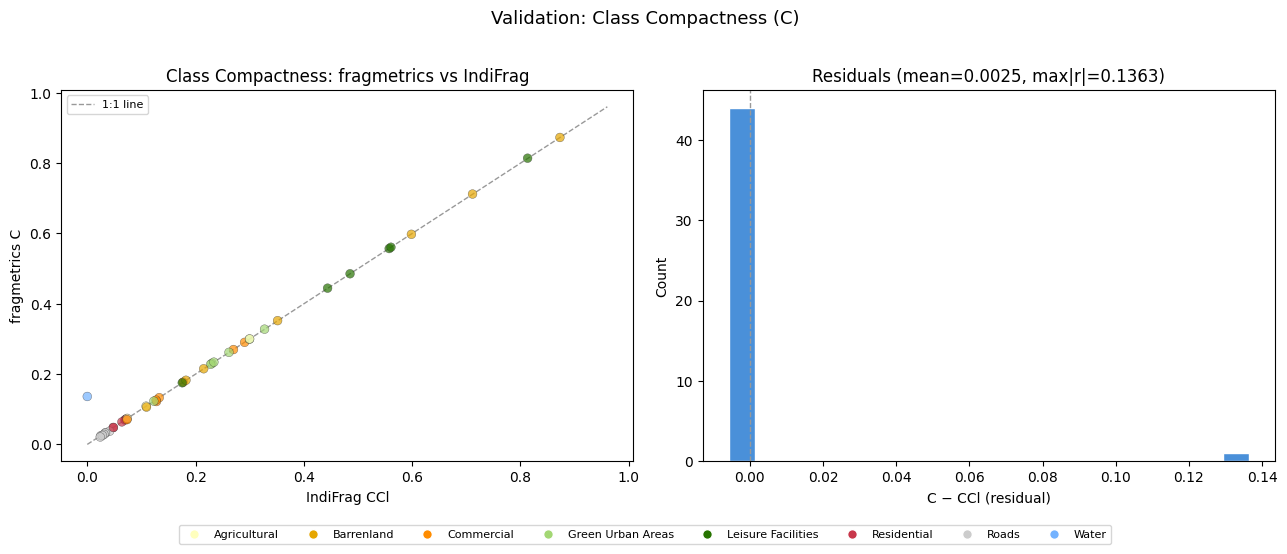

Number of class-SO groups: 45
Mean absolute error: 0.003789
Max absolute error:  0.136298
Correlation:         0.995706


In [21]:
# Validate C against CCl from expected results
comp_c = cl_agg[["CLASS", "SO", "C"]].merge(
    exp_cl[["CLASS", "SO", "CCl"]],
    on=["CLASS", "SO"],
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: C vs CCl
lo = min(comp_c["C"].min(), comp_c["CCl"].min()) * 0.9
hi = max(comp_c["C"].max(), comp_c["CCl"].max()) * 1.1
axes[0].plot([lo, hi], [lo, hi], "--", color="#999999", linewidth=1, label="1:1 line")
scatter = axes[0].scatter(
    comp_c["CCl"], comp_c["C"], s=40, alpha=0.7,
    c=[CLASS_COLORS.get(c, "grey") for c in comp_c["CLASS"]],
    edgecolors="#333333", linewidth=0.3, zorder=3,
)
axes[0].set_xlabel("IndiFrag CCl")
axes[0].set_ylabel("fragmetrics C")
axes[0].set_title("Class Compactness: fragmetrics vs IndiFrag")
axes[0].legend(fontsize=8)

# Residuals histogram
residuals = comp_c["C"] - comp_c["CCl"]
axes[1].hist(residuals, bins=20, color="#4a90d9", edgecolor="white")
axes[1].axvline(0, color="#999999", linestyle="--", linewidth=1)
axes[1].set_xlabel("C − CCl (residual)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residuals (mean={residuals.mean():.4f}, max|r|={residuals.abs().max():.4f})")

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=CLASS_COLORS[c],
           markersize=7, label=CLASS_NAMES[c])
    for c in sorted(CLASS_COLORS.keys())
]
fig.legend(handles=legend_elements, loc="lower center", ncol=8, fontsize=8,
           bbox_to_anchor=(0.5, -0.06))

plt.suptitle("Validation: Class Compactness (C)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/01_validation_C.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary statistics
print(f"Number of class-SO groups: {len(comp_c)}")
print(f"Mean absolute error: {residuals.abs().mean():.6f}")
print(f"Max absolute error:  {residuals.abs().max():.6f}")
print(f"Correlation:         {comp_c['C'].corr(comp_c['CCl']):.6f}")

---

**Next:** Diversity metrics (NCl, DSHAN, USHAN, SIMP, DD, IFFR, IFFA)
and Contrast metrics (RCB) will be added in the next iteration of this notebook.